<a href="https://colab.research.google.com/github/aloyuche/Blogg/blob/master/CustomerChurn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv(r"/content/customer_churn.csv")
df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [4]:
df.drop(['Names','Location','Company','Onboard_date'],axis=1, inplace= True)

In [5]:
df.dtypes

,0
Age,float64
Total_Purchase,float64
Account_Manager,int64
Years,float64
Num_Sites,float64
Churn,int64


In [6]:
def sigmoid(z):
  return 1/(1+np.exp(-z))

In [7]:
# cost function
def costFunction(X, y, theta):
    m = len(y)
    h = sigmoid(X.dot(theta))
    error = (y*np.log(h) + (1-y)*np.log(1-h))
    cost = -1/m * sum(error)
    grad = 1/m * X.T.dot(h-y)
    return cost, grad

In [8]:
# gradient descent
def gradientDescent(X, y, theta, alpha, iterations):
    cost_history = np.zeros(iterations)
    for i in range(iterations):
        cost, grad = costFunction(X, y, theta)
        theta -= alpha * grad
        cost_history[i] = cost
    return theta, cost_history

In [9]:
# predict function
def predict(X, theta):
    return sigmoid(X.dot(theta))

# accuracy function
def accuracy(y_true, y_pred):
    accuracy = np.sum(y_true == y_pred) / len(y_true)
    return accuracy

# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Churn', axis=1), df['Churn'], test_size=0.2, random_state=42)

# feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# add intercept
X_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test = np.c_[np.ones((X_test.shape[0], 1)), X_test]

Text(0.5, 1.0, 'Cost history')

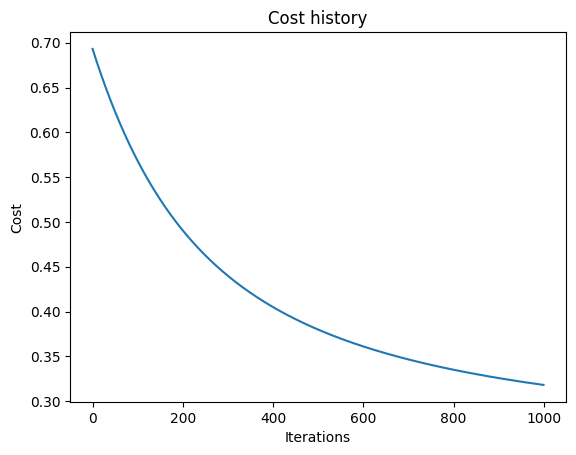

In [10]:
# train model
theta, cost_history = gradientDescent(X_train, y_train, np.zeros(X_train.shape[1]), alpha=0.01, iterations=1000)
# plot cost history
plt.plot(range(1000), cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost history')

In [12]:
y_pred  = predict(X_test, theta)
y_pred = [1 if i > 0.5 else 0 for i in y_pred]

In [13]:
accuracy(y_test, y_pred) *100

np.float64(88.88888888888889)

In [14]:
df1 = pd.read_csv(r"/content/new_customers_1.csv")
df1.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company
0,Andrew Mccall,37.0,9935.53,1,7.71,8.0,2011-08-29 18:37:54,38612 Johnny Stravenue Nataliebury WI 15717-8316,King Ltd
1,Michele Wright,23.0,7526.94,1,9.28,15.0,2013-07-22 18:19:54,"21083 Nicole Junction Suite 332, Youngport ME ...",Cannon-Benson
2,Jeremy Chang,65.0,100.00,1,1.00,15.0,2006-12-11 07:48:13,085 Austin Views Lake Julialand WY 63726-4298,Barron-Robertson
3,Megan Ferguson,32.0,6487.50,0,9.40,14.0,2016-10-28 05:32:13,922 Wright Branch North Cynthialand NC 64721,Sexton-Golden
4,Taylor Young,32.0,13147.71,1,10.00,8.0,2012-03-20 00:36:46,Unit 0789 Box 0734 DPO AP 39702,Wood LLC


In [15]:
df1.drop(['Names','Location','Company','Onboard_date'],axis=1, inplace= True)

In [16]:
df1.head()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites
0,37.0,9935.53,1,7.71,8.0
1,23.0,7526.94,1,9.28,15.0
2,65.0,100.00,1,1.00,15.0
3,32.0,6487.50,0,9.40,14.0
4,32.0,13147.71,1,10.00,8.0


In [18]:
X_new = scaler.transform(df1)
X_new = np.c_[np.ones((X_new.shape[0], 1)), X_new]
y_pred_new = predict(X_new, theta)
y_pred_new = [1 if i > 0.5 else 0 for i in y_pred_new]
y_pred_new

# insert prediction into dataframe
df1['Churn'] = y_pred_new
df1

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
0,37.0,9935.53,1,7.71,8.0,0
1,23.0,7526.94,1,9.28,15.0,1
2,65.0,100.00,1,1.00,15.0,1
3,32.0,6487.50,0,9.40,14.0,1
4,32.0,13147.71,1,10.00,8.0,0
5,22.0,8445.26,1,3.46,14.0,1


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [20]:
df = pd.read_csv(r"/content/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# **Data Overview**

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [24]:
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [25]:
df.duplicated().sum()

np.int64(0)

## **Missing and Invalid Values Analysis**

In [33]:
# Columns where 0 is not a valid value
zero_invalid = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Count of 0 values (likely missing):")
print("-" * 35)
for col in zero_invalid:
    count = (df[col] == 0).sum()
    pct = count / len(df) * 100
    print(f"{col:25s}: {count:3d} ({pct:.1f}%)")

Count of 0 values (likely missing):
-----------------------------------
Glucose                  :   5 (0.7%)
BloodPressure            :  35 (4.6%)
SkinThickness            : 227 (29.6%)
Insulin                  : 374 (48.7%)
BMI                      :  11 (1.4%)


# Visualize missing value pattern

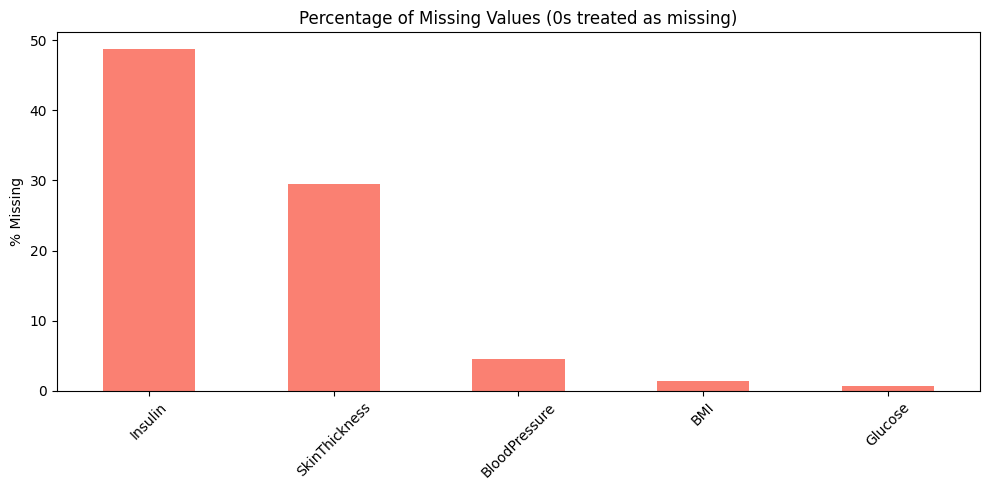

In [35]:
# Visualize missing value pattern
df_missing = df.copy()
for col in zero_invalid:
    df_missing[col] = df_missing[col].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(10, 5))
missing_pct = (df_missing.isnull().sum() / len(df_missing) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
missing_pct.plot(kind="bar", color="salmon", ax=ax)
ax.set_title("Percentage of Missing Values (0s treated as missing)")
ax.set_ylabel("% Missing")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1217/1529904699.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Outcome", data=df, palette="Set2", ax=axes[0])
/tmp/ipykernel_1217/1529904699.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No Diabetes", "Diabetes"])


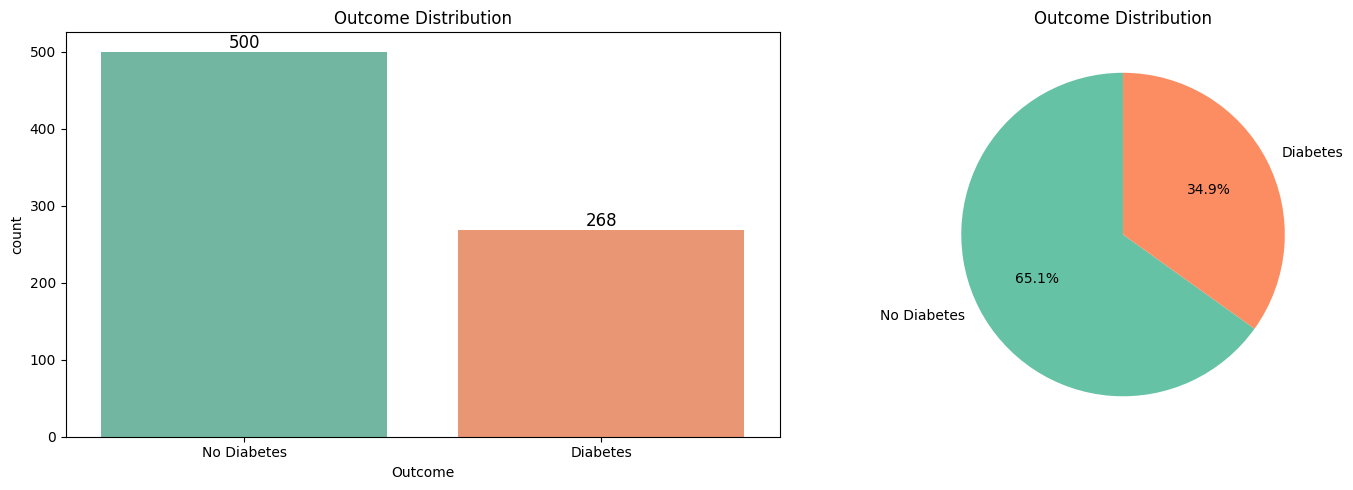

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
#count plot
sns.countplot(x="Outcome", data=df, palette="Set2", ax=axes[0])
axes[0].set_xticklabels(["No Diabetes", "Diabetes"])
axes[0].set_title("Outcome Distribution")

# Add count on bar
# Add counts on bars
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="bottom", fontsize=12)
# Pie Chart
df ["Outcome"].value_counts().plot.pie(
    labels=["No Diabetes", "Diabetes"],
    autopct="%1.1f%%",
    colors=["#66c2a5", "#fc8d62"],
    startangle=90,
    ax=axes[1]
)
axes[1].set_ylabel("")
axes[1].set_title("Outcome Distribution")
plt.tight_layout()
plt.show()





In [45]:
print(f"\nClass balance:")
print(df["Outcome"].value_counts())
print(f"\nDiabetes rate: {df['Outcome'].mean():.1%}")


Class balance:
Outcome
0    500
1    268
Name: count, dtype: int64

Diabetes rate: 34.9%


#**6. Univariate Analysis**

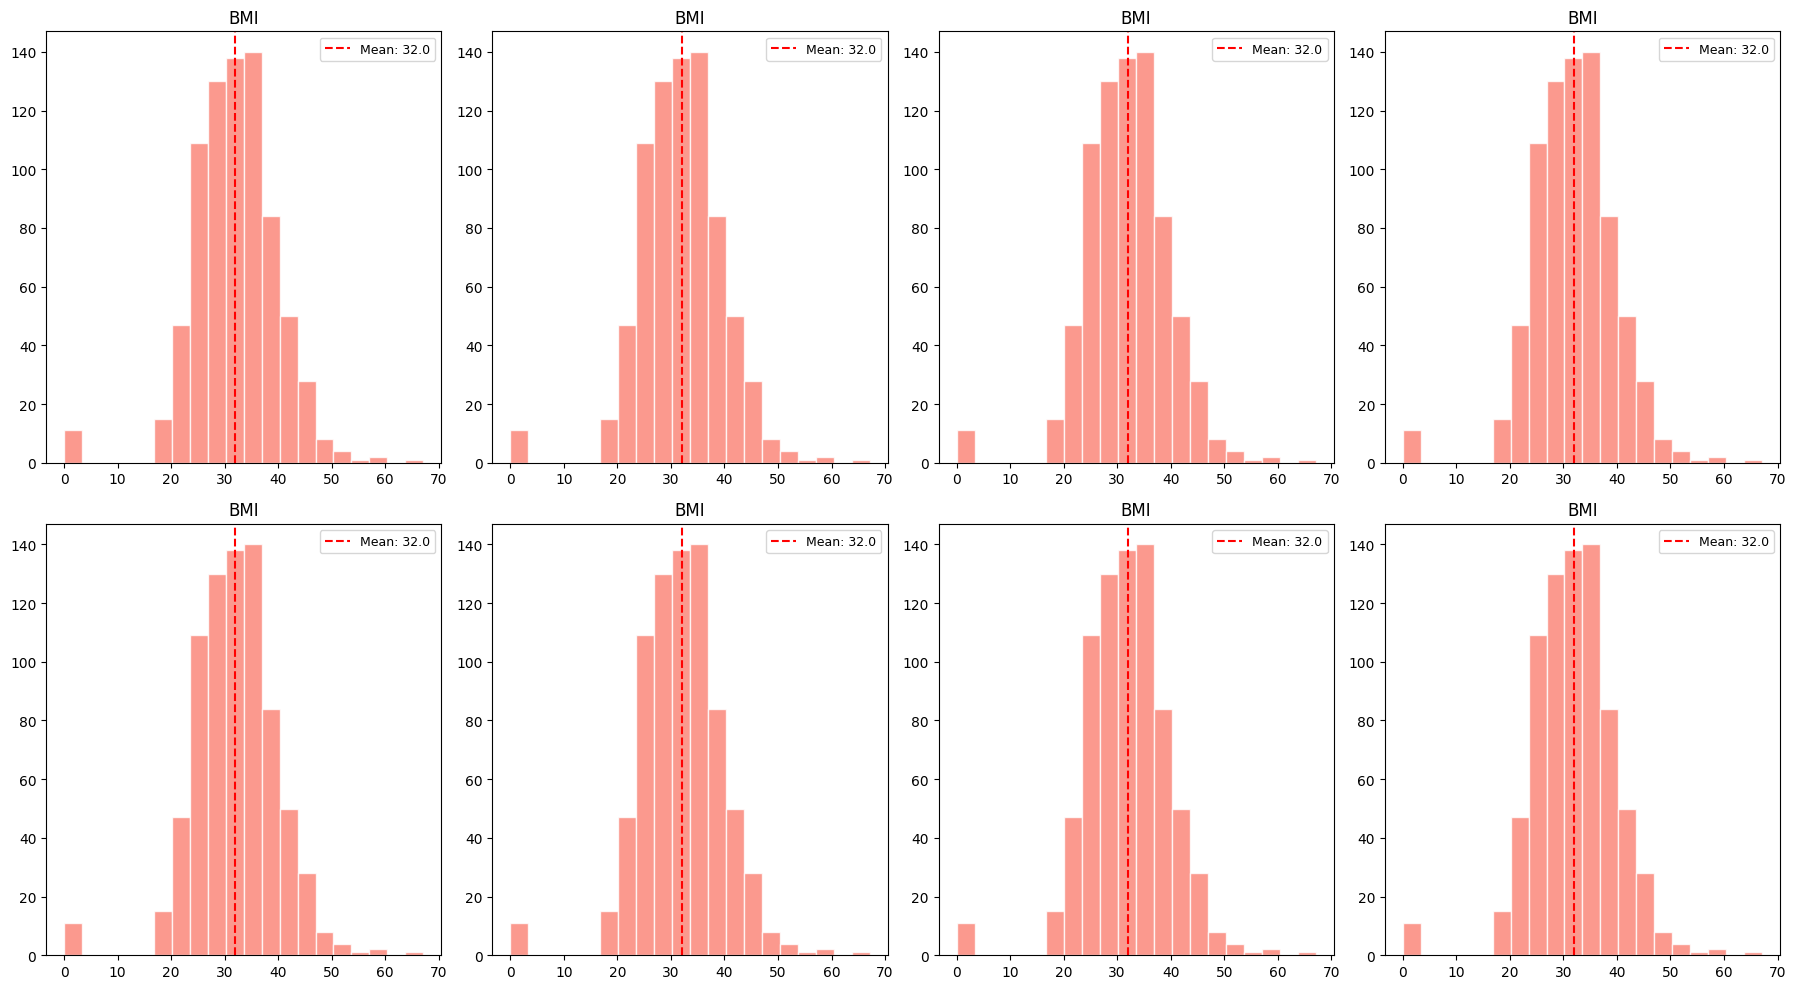

In [48]:
features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
            "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
for i, feature in enumerate(features):
  axes[i].hist(df[col], bins=20, color="salmon", edgecolor ="white", alpha= 0.8)
  axes[i].set_title(col)
  axes[i].axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean: {df[col].mean():.1f}")
  axes[i].legend(fontsize=9)
plt.tight_layout()
plt.show()

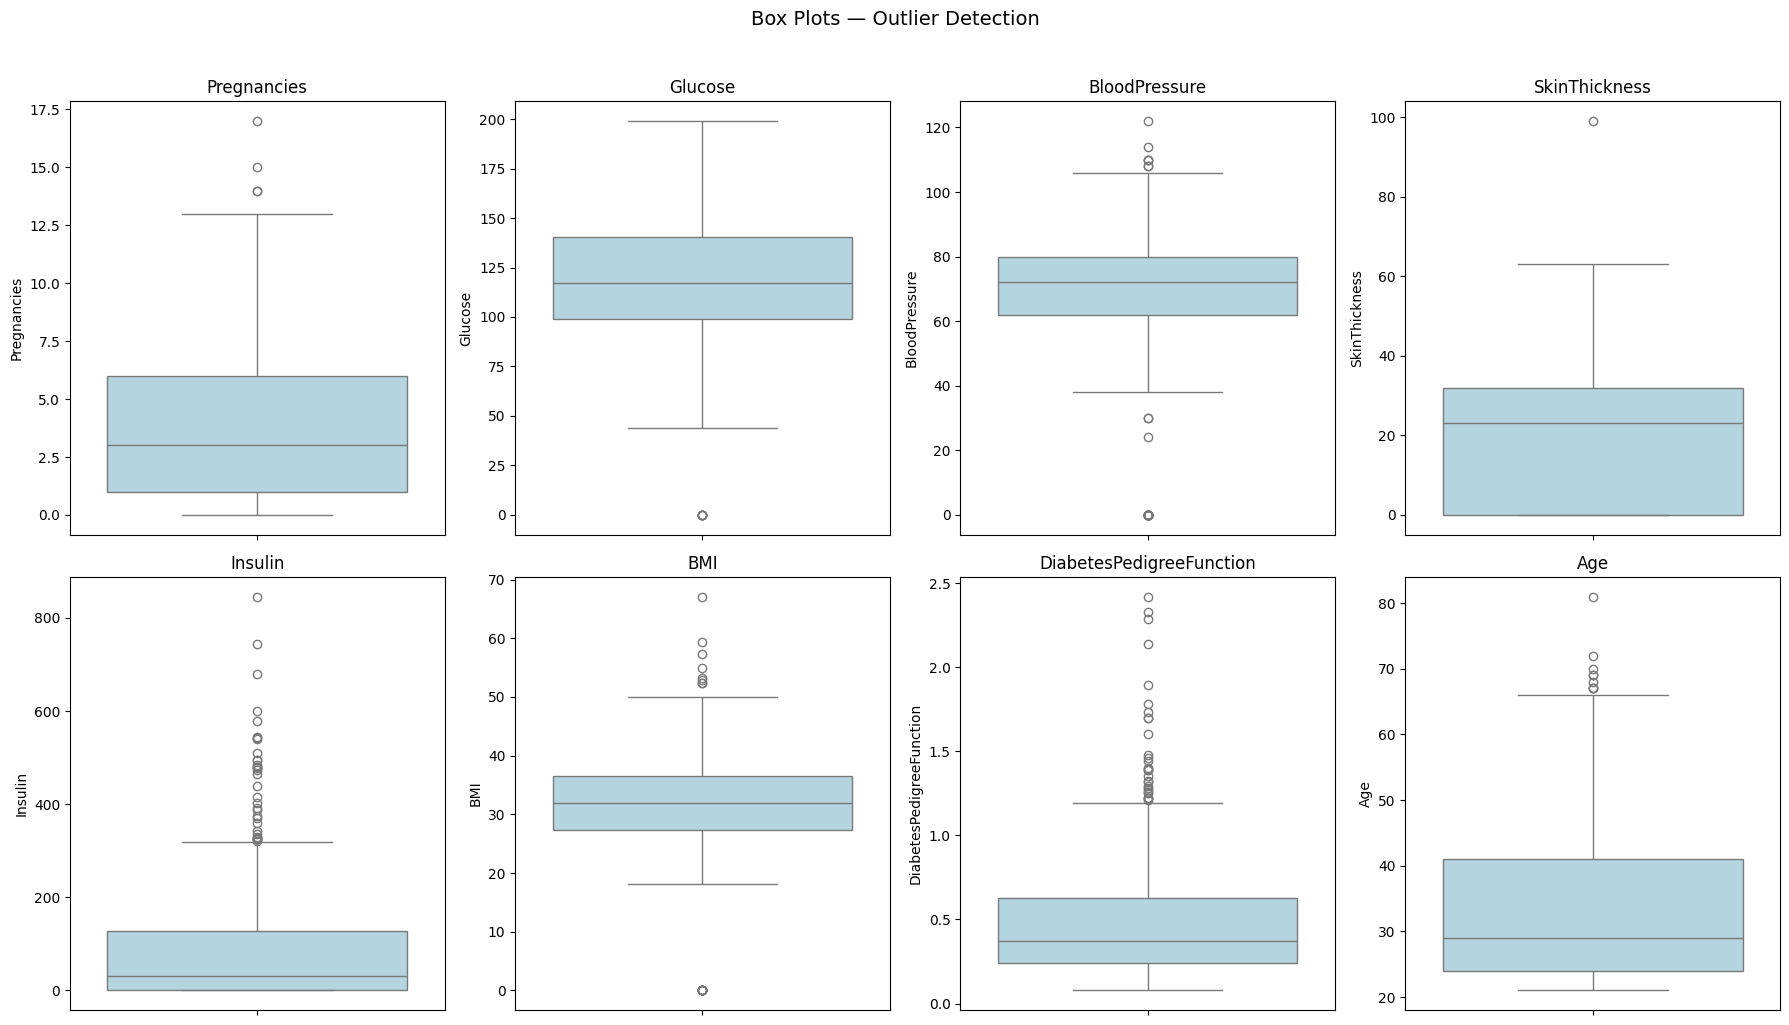

In [49]:
# Box plots to spot outliers
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color="lightblue")
    axes[i].set_title(col)

plt.suptitle("Box Plots — Outlier Detection", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

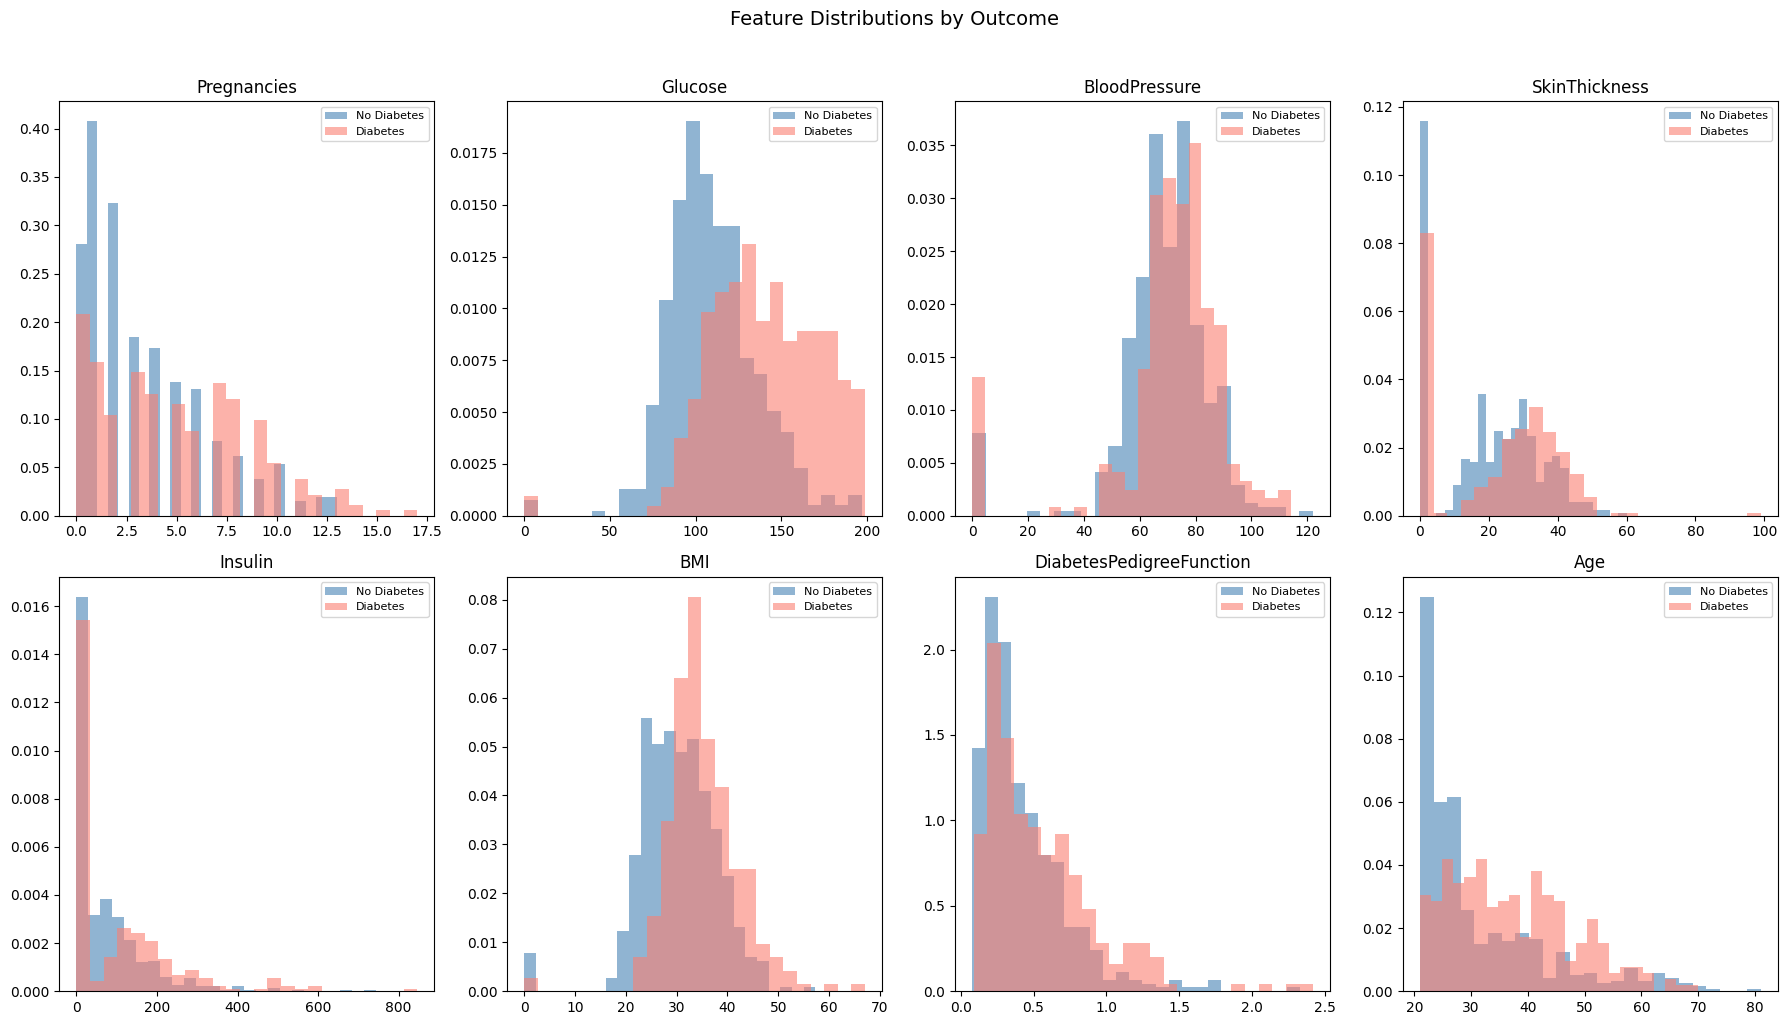

In [50]:
# Distribution of each feature split by outcome
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    for outcome, color, label in [(0, "steelblue", "No Diabetes"), (1, "salmon", "Diabetes")]:
        subset = df[df["Outcome"] == outcome][col]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle("Feature Distributions by Outcome", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [51]:
# Mean feature values by outcome
comparison = df.groupby("Outcome")[features].mean().T
comparison.columns = ["No Diabetes", "Diabetes"]
comparison["Difference"] = comparison["Diabetes"] - comparison["No Diabetes"]
comparison["% Higher"] = (comparison["Difference"] / comparison["No Diabetes"] * 100).round(1)
comparison.round(2)

,No Diabetes,Diabetes,Difference,% Higher
Pregnancies,3.30,4.87,1.57,47.5
Glucose,109.98,141.26,31.28,28.4
BloodPressure,68.18,70.82,2.64,3.9
SkinThickness,19.66,22.16,2.50,12.7
Insulin,68.79,100.34,31.54,45.9
BMI,30.30,35.14,4.84,16.0
DiabetesPedigreeFunction,0.43,0.55,0.12,28.1
Age,31.19,37.07,5.88,18.8


/tmp/ipykernel_1217/2490985529.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Outcome", y=col, data=df, palette="Set2", ax=axes[i])
/tmp/ipykernel_1217/2490985529.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No Diabetes", "Diabetes"])
/tmp/ipykernel_1217/2490985529.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Outcome", y=col, data=df, palette="Set2", ax=axes[i])
/tmp/ipykernel_1217/2490985529.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels([

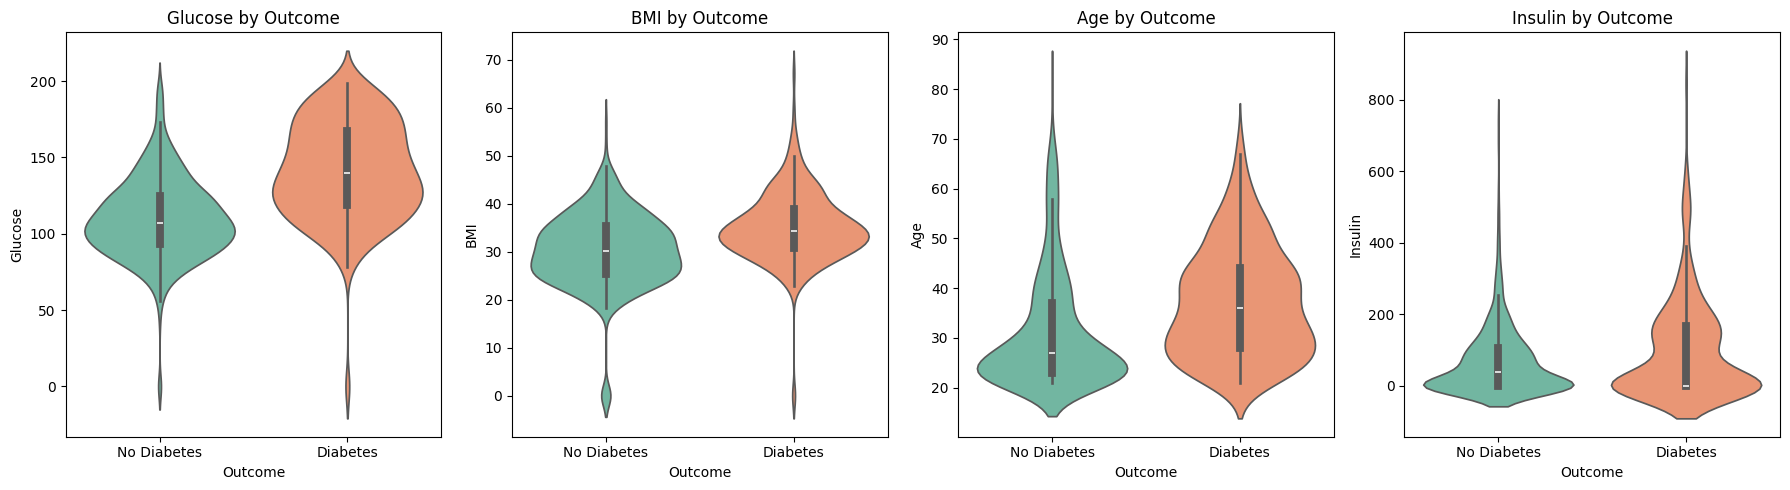

In [52]:
# Violin plots for key features
key_features = ["Glucose", "BMI", "Age", "Insulin"]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(key_features):
    sns.violinplot(x="Outcome", y=col, data=df, palette="Set2", ax=axes[i])
    axes[i].set_xticklabels(["No Diabetes", "Diabetes"])
    axes[i].set_title(f"{col} by Outcome")

plt.tight_layout()
plt.show()

## ***Correlation Analysis***

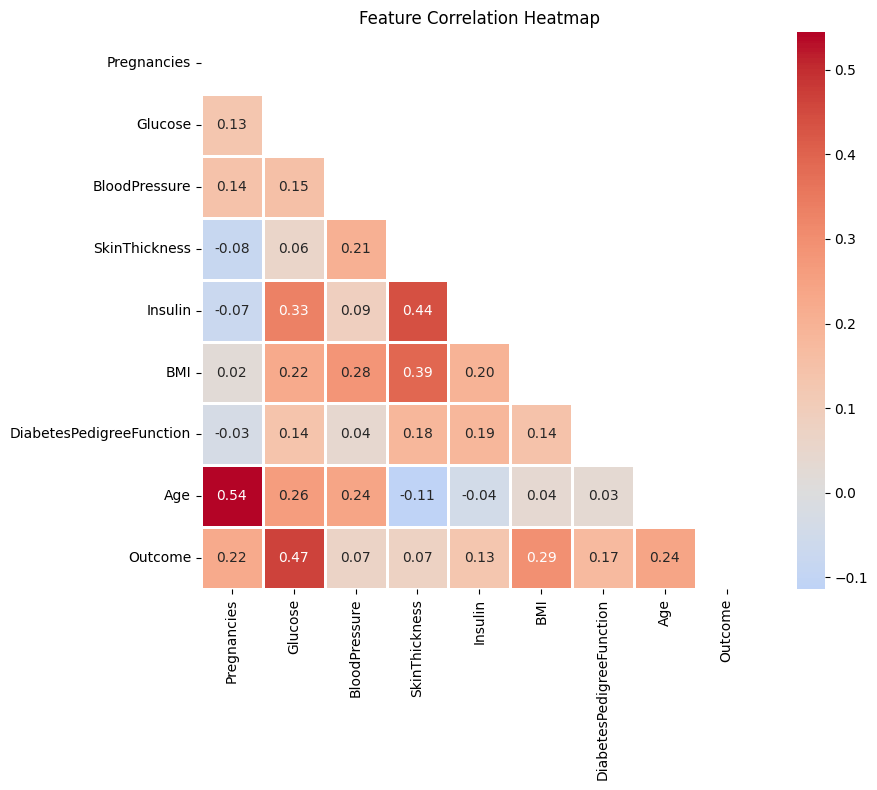

In [53]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=1)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

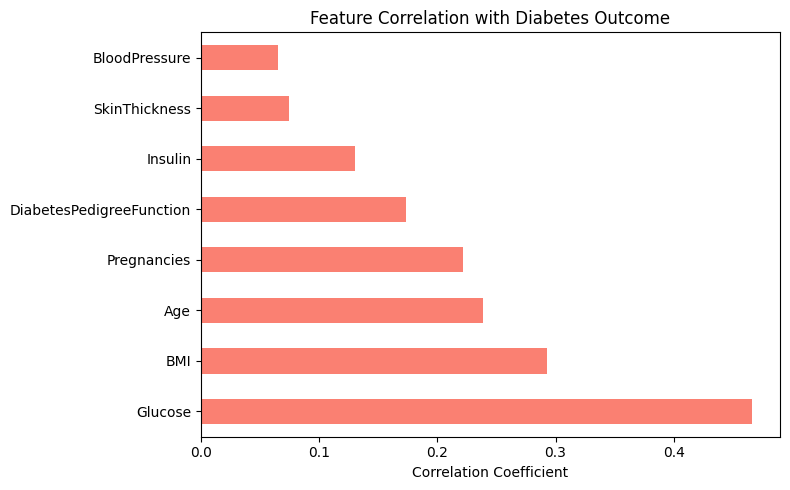

Correlation with Outcome:
Glucose                     0.467
BMI                         0.293
Age                         0.238
Pregnancies                 0.222
DiabetesPedigreeFunction    0.174
Insulin                     0.131
SkinThickness               0.075
BloodPressure               0.065
Name: Outcome, dtype: float64


In [54]:
# Correlation with target
target_corr = df.corr()["Outcome"].drop("Outcome").sort_values(ascending=False)

plt.figure(figsize=(8, 5))
target_corr.plot(kind="barh", color=["salmon" if x > 0 else "steelblue" for x in target_corr])
plt.title("Feature Correlation with Diabetes Outcome")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

print("Correlation with Outcome:")
print(target_corr.round(3))

#9. **Age and Pregnancy Analysis**

/tmp/ipykernel_1217/573116940.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_diabetes = df.groupby("AgeGroup")["Outcome"].mean() * 100
/tmp/ipykernel_1217/573116940.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  preg_diabetes = df.groupby("Preg_Group")["Outcome"].mean() * 100


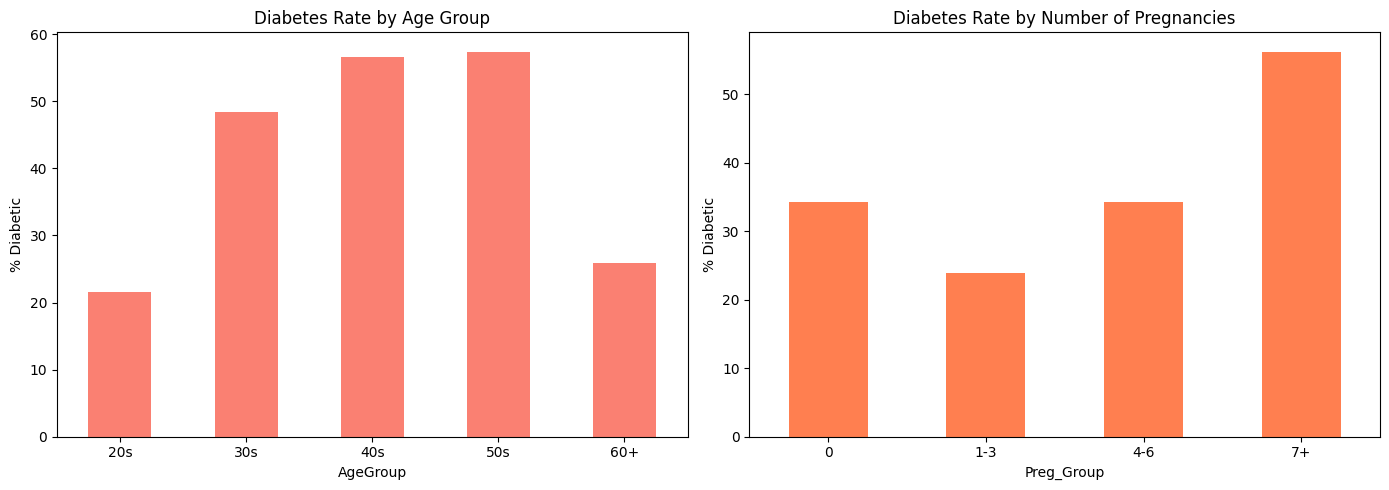

In [55]:
# Diabetes rate by age group
df["AgeGroup"] = pd.cut(df["Age"], bins=[20, 30, 40, 50, 60, 90], labels=["20s", "30s", "40s", "50s", "60+"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Diabetes rate by age group
age_diabetes = df.groupby("AgeGroup")["Outcome"].mean() * 100
age_diabetes.plot(kind="bar", color="salmon", ax=axes[0])
axes[0].set_title("Diabetes Rate by Age Group")
axes[0].set_ylabel("% Diabetic")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Diabetes rate by pregnancy count
df["Preg_Group"] = pd.cut(df["Pregnancies"], bins=[-1, 0, 3, 6, 20], labels=["0", "1-3", "4-6", "7+"])
preg_diabetes = df.groupby("Preg_Group")["Outcome"].mean() * 100
preg_diabetes.plot(kind="bar", color="coral", ax=axes[1])
axes[1].set_title("Diabetes Rate by Number of Pregnancies")
axes[1].set_ylabel("% Diabetic")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Drop temporary columns
df.drop(columns=["AgeGroup", "Preg_Group"], inplace=True)

# **Glucose and BMI Deep Dive Analysis**

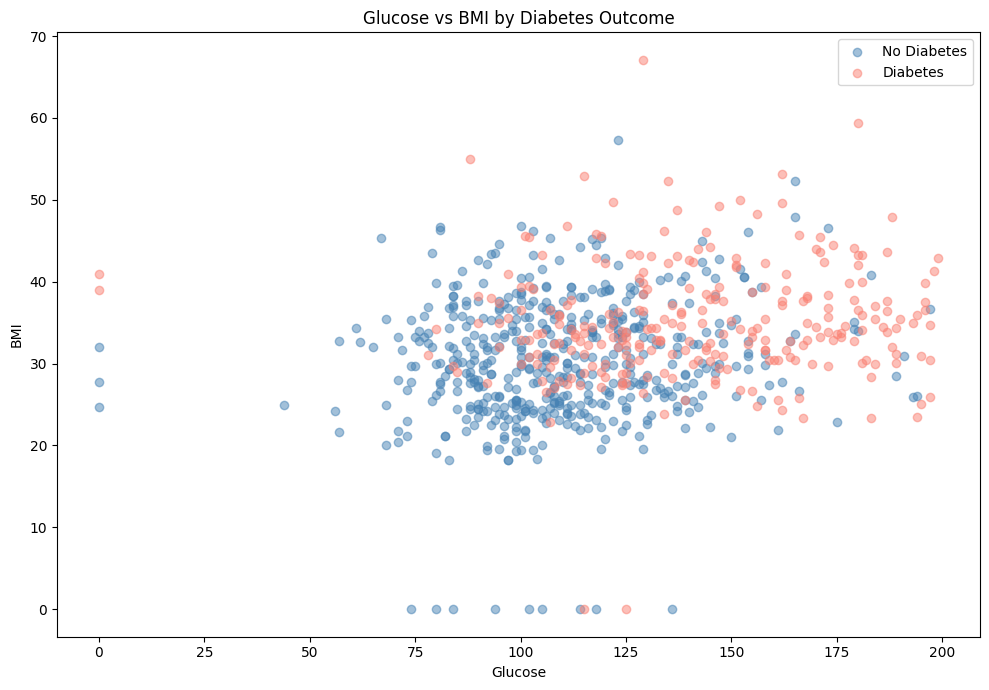

In [56]:
# Scatter plot: Glucose vs BMI colored by Outcome
plt.figure(figsize=(10, 7))
colors = {0: "steelblue", 1: "salmon"}
for outcome in [0, 1]:
    subset = df[df["Outcome"] == outcome]
    plt.scatter(subset["Glucose"], subset["BMI"],
                c=colors[outcome], alpha=0.5,
                label="Diabetes" if outcome else "No Diabetes")

plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Glucose vs BMI by Diabetes Outcome")
plt.legend()
plt.tight_layout()
plt.show()

In [57]:
# Glucose thresholds
print("Diabetes rate by glucose level:")
print("-" * 40)
for label, low, high in [("Normal (<100)", 0, 100), ("Prediabetes (100-126)", 100, 126), ("Diabetes (>126)", 126, 300)]:
    subset = df[(df["Glucose"] >= low) & (df["Glucose"] < high)]
    rate = subset["Outcome"].mean() * 100
    print(f"  {label:25s}: {rate:.1f}% (n={len(subset)})")


Diabetes rate by glucose level:
----------------------------------------
  Normal (<100)            : 8.1% (n=197)
  Prediabetes (100-126)    : 27.7% (n=274)
  Diabetes (>126)          : 59.3% (n=297)


### **Pair Plot**

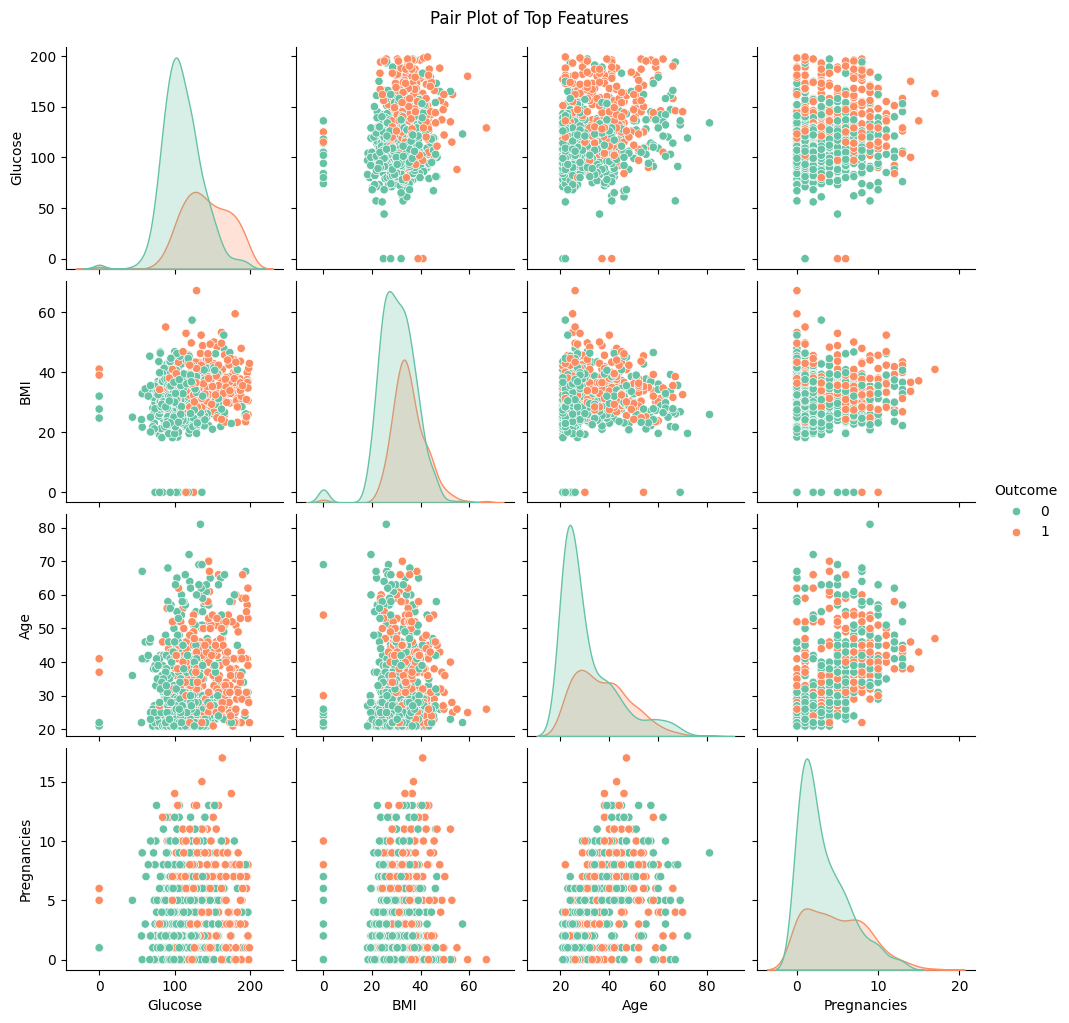

In [59]:
# Pair plot for top correlated features
top_features = ["Glucose", "BMI", "Age", "Pregnancies", "Outcome"]
sns.pairplot(df[top_features], hue="Outcome", palette="Set2", diag_kind="kde")
plt.suptitle("Pair Plot of Top Features", y=1.02)
plt.show()